In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
orders = pd.read_csv('data/olist_orders_dataset.csv')
items = pd.read_csv('data/olist_order_items_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv') # Caso tenha essa tabela
translation = pd.read_csv('data/product_category_name_translation.csv')

In [3]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [4]:
df_sales = pd.merge(items, orders, on='order_id')

## EDA 1: Volume de Vendas ao Longo do Tempo (Sazonalidade)

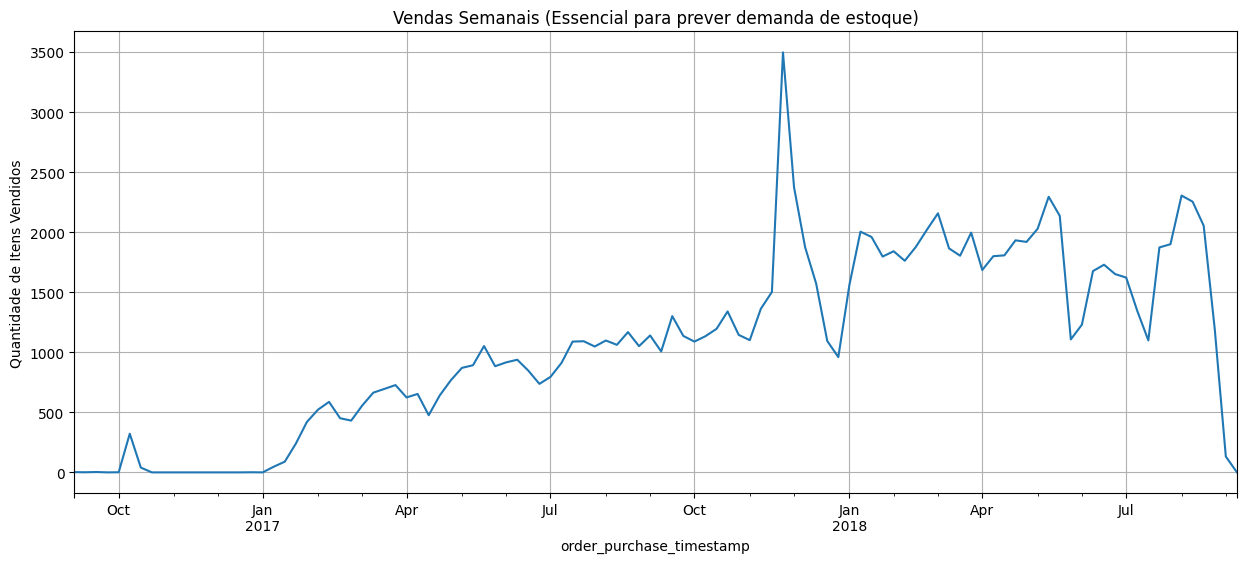

In [5]:
plt.figure(figsize=(15, 6))
df_sales.set_index('order_purchase_timestamp').resample('W')['order_item_id'].count().plot()
plt.title('Vendas Semanais (Essencial para prever demanda de estoque)')
plt.ylabel('Quantidade de Itens Vendidos')
plt.grid(True)
plt.show()

## EDA 2: Top 10 Categorias que mais giram estoque

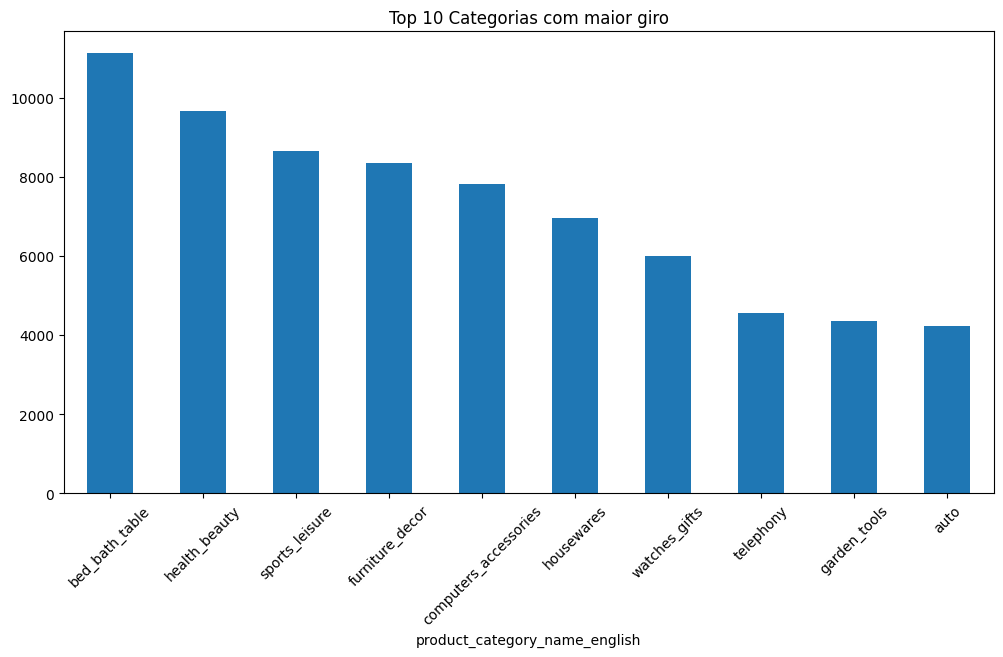

In [6]:
# (Unindo com tradução para facilitar a leitura)
if 'product_id' in products.columns:
    items_prod = pd.merge(items, products[['product_id', 'product_category_name']], on='product_id')
    items_prod = pd.merge(items_prod, translation, on='product_category_name')
    
    plt.figure(figsize=(12, 6))
    items_prod['product_category_name_english'].value_counts().head(10).plot(kind='bar')
    plt.title('Top 10 Categorias com maior giro')
    plt.xticks(rotation=45)
    plt.show()

## EDA 3: Análise de Lead Time (Tempo de Entrega Real vs Estimado)

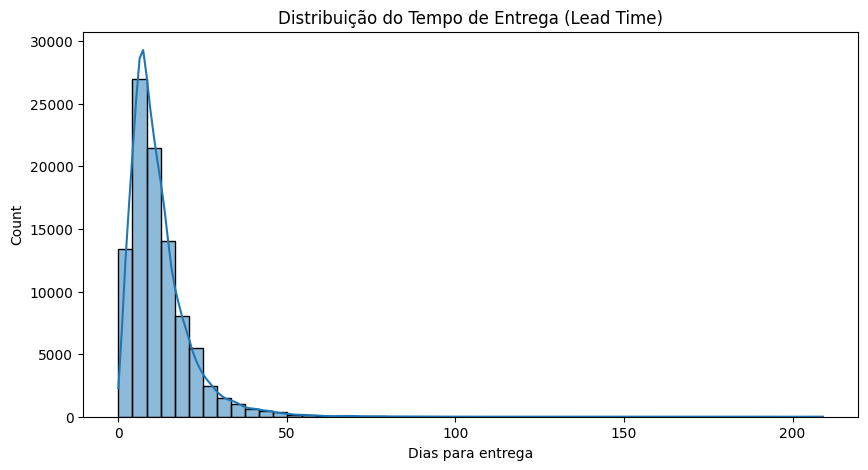

In [7]:
orders['delivery_time'] = (pd.to_datetime(orders['order_delivered_customer_date']) - 
                           pd.to_datetime(orders['order_purchase_timestamp'])).dt.days

plt.figure(figsize=(10, 5))
sns.histplot(orders['delivery_time'].dropna(), bins=50, kde=True)
plt.title('Distribuição do Tempo de Entrega (Lead Time)')
plt.xlabel('Dias para entrega')
plt.show()

## EDA 4: Concentração de Vendas por Vendedor

In [8]:
seller_counts = items['seller_id'].value_counts()
print(f"Total de vendedores: {len(seller_counts)}")
print(f"Média de itens por vendedor: {seller_counts.mean():.2f}")

Total de vendedores: 3095
Média de itens por vendedor: 36.40
